<div style="width:100%; background-color:#181818; color:#f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExcXVodWNsM3Bia3duZGljZzRqMTI2MGFiZjlkZzBwcmhuaWxydjlpaiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/AOSwwqVjNZlDO/giphy.gif" alt="Beam Oscillation" width="400" style="border-radius:10px;">

  <h3 style="color:#ffffff; margin-top:15px;"><b>Manual Flexural Method. all deformations</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:#3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Matrix Analisys</p>
  <p><b>Year:</b> APRIL - 2026</p>

</div>

#### Libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

![alt text](image-10.png)

![alt text](image-11.png)

![alt text](image-12.png)

![alt text](image-13.png)

#### Data

In [19]:
w = 2                       # T/m
L = 4                       # m
vb = 0.30                   # m
vh = 0.30                   # m
E = 2100000                 # T/m2
T1 = 9                      # celcius
T2 = 18                     # celcius
alfa = 9.9e-6               # m/m/celcius
dP = 0.008                  # previus deformation
dR1 = 0.001                 # rad
dR2 = 0.009                 # m
dR3 = 0.012                 # m

#------- Geometry---------
XF = np.array([0, L/2, L, L, L + L/2, L + L, L + L, 2*L + L/2, 2*L + L/2, 3*L])
YF = np.zeros(len(XF))

#### Calculations

In [20]:
I = vb*vh**3 / 12

##### Flex Matrix

###### Q1 = 1; Q2 = 0; Q3 = 0
![alt text](image-16.png)

###### Q2 = 1; Q1 = 0; Q3 = 0
![alt text](image-17.png)
###### Q3 = 1; Q1 = 0; Q2 = 0
![alt text](image-18.png)


In [21]:
F11 = L / (3*E*I)
F21 = -L / (6*E*I)
F31 = 0
F12 = F21
F22 = 2*L / (3*E*I)
F32 = L / (6*E*I)
F13 = F31
F23 = F32
F33 = 2*L / (3*E*I)

F = np.array([[F11, F12, F13],
              [F21, F22, F23],
              [F31, F32, F33]])

F_df = pd.DataFrame(F, columns=['Q1','Q2','Q3'], index = ['Q1','Q2','Q3'])
F_df

,Q1,Q2,Q3
Q1,0.000941,-0.000470,0.000000
Q2,-0.000470,0.001881,0.000470
Q3,0.000000,0.000470,0.001881


##### Displacement vector corresponding to the redundants in the real structure $\{D_Q\}$
![alt text](image-25.png)

In [22]:
DQ = np.array([[-dR1],
               [0],
               [0]])

DQ_df = pd.DataFrame(DQ, columns=['DQ'], index = ['Q1','Q2','Q3'])
DQ_df

,DQ
Q1,-0.001
Q2,0.000
Q3,0.000


##### Displacement vector corresponding to the redundants due to real loads in the released or statically determinate structure

$$ \{D_{QL}\}=
\begin{bmatrix}
D_{QL1} \\
D_{QL2} \\
\vdots \\
D_{QLn}
\end{bmatrix}
$$

In [23]:
DQL = np.array([[-w*L**3 / (24*E*I)],
                [w*L**3 / (24*E*I)],
                [w*L**3 / (16*E*I)]])

DQL_df = pd.DataFrame(DQL, columns=['DQL'], index = ['Q1','Q2','Q3'])
DQL_df

,DQL
Q1,-0.003762
Q2,0.003762
Q3,0.005644


##### Displacement vector corresponding to the redundants due to temperature effects in the released or statically determinate structure

$$\{D_{QT}\}=
\begin{bmatrix}
D_{QT1} \\
D_{QT2} \\
\vdots \\
D_{QTn}
\end{bmatrix}
$$

In [24]:
DQT = L /2 * (alfa*(T1-T2)) / vh * np.array([[-1],
                                             [2],
                                             [2]])

DQT_df = pd.DataFrame(DQT, columns=['DQT'], index = ['Q1','Q2','Q3'])
DQT_df

,DQT
Q1,0.000594
Q2,-0.001188
Q3,-0.001188


##### Displacement vector corresponding to the redundants due to initial deformations in the released or statically determinate structure

$$ \{D_{QP}\}\begin{bmatrix}
D_{QP1} \\
D_{QP2} \\
\vdots \\
D_{QPn}
\end{bmatrix}
$$

In [25]:
DQP = np.array([[0],
                [dP/L],
                [-2*dP/L]])

DQP_df = pd.DataFrame(DQP, columns=['DQP'], index = ['Q1','Q2','Q3'])
DQP_df

,DQP
Q1,0.000
Q2,0.002
Q3,-0.004


##### Displacement vector corresponding to the redundants due to support displacements in the released or statically determinate structure

$$\{D_{QR}\}=
\begin{bmatrix}
D_{QR1} \\
D_{QR2} \\
\vdots \\
D_{QRn}
\end{bmatrix}
$$

In [26]:
DQR = np.array([[-dR2/L],
                [-2*dR2/L + dR3/L],
                [dR2/L - 2*dR3/L]])

DQR_df = pd.DataFrame(DQR, columns=['DQR'], index = ['Q1','Q2','Q3'])
DQR_df

,DQR
Q1,-0.00225
Q2,-0.00150
Q3,-0.00375


#### Total displacement vector corresponding to the redundants in the released or statically determinate structure

$$\{D_{QS}\}=
\{D_{QL}\}
+
\{D_{QT}\}
+
\{D_{QP}\}
+
\{D_{QR}\}
$$

In [27]:
DQS = DQL + DQT + DQP + DQR

DQS_df = pd.DataFrame(DQS, columns=['DQS'], index = ['Q1','Q2','Q3'])
DQS_df

,DQS
Q1,-0.005418
Q2,0.003074
Q3,-0.003294


#### Calculation of redundants

$$\{Q\}=[F]^{-1}\left(\{D_Q\}-\{D_{QS}\}\right)
$$

In [28]:
#------------Due all deformations---------------
Q_all = np.linalg.inv(F) @ (DQ - DQS)
Q_all_df = pd.DataFrame(Q_all, columns=['Q due all deformations'])
#------------only due real loads---------------
Q_L = np.linalg.inv(F) @ (0 - DQL)
Q_L_df = pd.DataFrame(Q_L, columns=['Q due real loads'])
#------------only due climate effects---------------
Q_T = np.linalg.inv(F) @ (0 - DQT)
Q_T_df = pd.DataFrame(Q_T, columns=['Q due climate effects'])
#------------only due previus defformations---------------
Q_P = np.linalg.inv(F) @ (0 - DQP)
Q_P_df = pd.DataFrame(Q_P, columns=['Q due previus defformations'])
#------------only due support diplacement---------------
Q_R = np.linalg.inv(F) @ (0 - DQR)
Q_R_df = pd.DataFrame(Q_R, columns=['Q due support diplacement'])

Q = pd.concat([Q_all_df, Q_L_df, Q_T_df, Q_P_df, Q_R_df], axis = 1, ignore_index= False)
Q

,Q due all deformations,Q due real loads,Q due climate effects,Q due previus defformations,Q due support diplacement
0,4.144974,3.846154,-0.437190,-0.981346,2.944038
1,-1.104872,-0.307692,0.388613,-1.962692,1.104014
2,2.027324,-2.923077,0.534343,2.616923,1.717356


#### Member action vector (shear) in the real structure

$$\{AM\}_V=
\{AM_L\}_V
+
[AM_Q]_V\{Q\}
$$

Where:

- $\{AM\}_V$ = member action vector (shear) in the real structure.
- $\{AM_L\}_V$ = member action vector (shear) due to real loads in the released or statically determinate structure.
- $[AM_Q]_V$ = member action matrix (shear) due to unit redundants in the released or statically determinate structure.
- $\{Q\}$ = vector of redundants.

![alt text](image-31.png)

##### Calculation of Member action vector (shear) due to real loads in the released or statically determinate structure $\{AM\}$
![alt text](image-32.png)

In [29]:
AML_v = np.array([[w*L/2],
                [0],
                [-w*L/2],
                [0],
                [0],
                [0],
                [w*L/2],
                [w*L/2],
                [-w*L/2],
                [-w*L/2],
                ])

##### Calculation of Member action matrix (shear) due to unit redundants in the released or statically determinate structure. $[AM_Q]$}

###### Q1 = 1; Q2 = 0; Q3 = 0
![alt text](image-33.png)

###### Q2 = 1; Q1 = 0; Q3 = 0
![alt text](image-34.png)
###### Q3 = 1; Q1 = 0; Q2 = 0
![alt text](image-36.png)

In [30]:
AMQ_v = np.array([[1/L, 1/L, 0],
                [1/L, 1/L, 0],
                [1/L, 1/L, 0],
                [0, -1/L, 1/L],
                [0, -1/L, 1/L],
                [0, -1/L, 1/L],
                [0, 0, -1/L],
                [0, 0, -1/L],
                [0, 0, -1/L],
                [0, 0, -1/L],
                ])

##### Calculation of Member action vector (flexure) in the real structure $\{AM\} = \{AM_L\}+[AM_Q]\{Q\}$.

In [31]:
#------------Due all deformations---------------
AM_all_v = AML_v + (AMQ_v @ Q_all)
AM_all_v_df = pd.DataFrame(AM_all_v, columns=['AM due all deformations'])
#------------only due real loads---------------
AM_L_v = AML_v + (AMQ_v @ Q_L)
AM_L_v_df = pd.DataFrame(AM_L_v, columns=['AM due real loads'])
#------------only due climate effects---------------
AM_T_v = AML_v + (AMQ_v @ Q_T)
AM_T_v_df = pd.DataFrame(AM_T_v, columns=['AM due climate effects'])
#------------only due previus defformations---------------
AM_P_v = AML_v + (AMQ_v @ Q_P)
AM_P_v_df = pd.DataFrame(AM_P_v, columns=['AM due previus defformations'])
#------------only due support diplacement---------------
AM_R_v = AML_v + (AMQ_v @ Q_R)
AM_R_v_df = pd.DataFrame(AM_R_v, columns=['AM due support displacement'])

AM_v = pd.concat([AM_all_v_df, AM_L_v_df, AM_T_v_df, AM_P_v_df, AM_R_v_df], axis = 1, ignore_index= False)
AM_v


,AM due all deformations,AM due real loads,AM due climate effects,AM due previus defformations,AM due support displacement
0,4.760025,4.884615,3.987856,3.263990,5.012013
1,0.760025,0.884615,-0.012144,-0.736010,1.012013
2,-3.239975,-3.115385,-4.012144,-4.736010,-2.987987
3,0.783049,-0.653846,0.036432,1.144904,0.153335
4,0.783049,-0.653846,0.036432,1.144904,0.153335
5,0.783049,-0.653846,0.036432,1.144904,0.153335
6,3.493169,4.730769,3.866414,3.345769,3.570661
7,3.493169,4.730769,3.866414,3.345769,3.570661
8,-4.506831,-3.269231,-4.133586,-4.654231,-4.429339
9,-4.506831,-3.269231,-4.133586,-4.654231,-4.429339


##### For Plotting - FLEXION

In [32]:
AM_all_v = AM_all_v
AM_L_v = AM_L_v
AM_T_v = AM_T_v
AM_P_v = AM_P_v
AM_R_v = AM_R_v

In [33]:
class FlexuralPlotManual:
    def __init__(self, all_def=None, real_load=None, climate=None, previous=None, support=None, x_vals=None, ref_line=None, y_label='AM'):
        self.data_sets = [all_def, real_load, climate, previous, support]
        self.x_vals = x_vals
        self.ref_line = ref_line
        self.y_label = y_label

    def plot(self):
        x = self.x_vals
        y_ref = self.ref_line
        span = x[-1] - x[0]

        fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(18, 18))

        configs = [
            {"color": "#ffcc00", "fill": "#fff3b0", "title": "All Deformations", "ls": "-"},   # amarillo
            {"color": "#00b4d8", "fill": "#caf0f8", "title": "Real Loads", "ls": "-"},        # celeste fuerte
            {"color": "#d00000", "fill": "#ffccd5", "title": "Climate Effects", "ls": "-"},   # rojo
            {"color": "#2dc653", "fill": "#d8f3dc", "title": "Previous Deformations", "ls": "-"}, # verde
            {"color": "#6c757d", "fill": "#dee2e6", "title": "Support Displacement", "ls": "--"}, # gris
        ]

        for idx, (data, cfg) in enumerate(zip(self.data_sets, configs)):
            ax = axes[idx]

            ax.plot(x, y_ref, color="black", linewidth=2, marker="o", markersize=8, markerfacecolor="white")

            ax.plot(x, data, color=cfg["color"], linestyle=cfg["ls"], marker="D", markersize=5, label=cfg["title"])

            alpha_val = 0.25 if idx == 4 else 0.45
            ax.fill_between(x, data, color=cfg["fill"], alpha=alpha_val)

            for xi, yi in zip(x, data):
                ax.text(xi, yi, f"{yi:.2f}", fontsize=9, ha="center", va="bottom")

            ax.set_title(f"Shear Diagram - {cfg['title']}", fontweight="bold")
            ax.set_xlabel("Distance [m]")
            ax.set_ylabel(self.y_label)
            ax.set_xlim([x[0] - span * 0.1, x[-1] + span * 0.1])
            ax.legend()

        ax = axes[5]
        ax.plot(x, y_ref, color="black", linewidth=2, marker="o", markersize=8, markerfacecolor="white")

        for data, cfg in zip(self.data_sets, configs):
            ax.plot(x, data, color=cfg["color"], linestyle=cfg["ls"], marker="D", markersize=5, label=cfg["title"])

        ax.set_title("Shear Diagram - Comparison", fontweight="bold")
        ax.set_xlabel("Distance [m]")
        ax.set_ylabel(self.y_label)
        ax.set_xlim([x[0] - span * 0.1, x[-1] + span * 0.1])
        ax.legend()

        plt.tight_layout()
        plt.show()

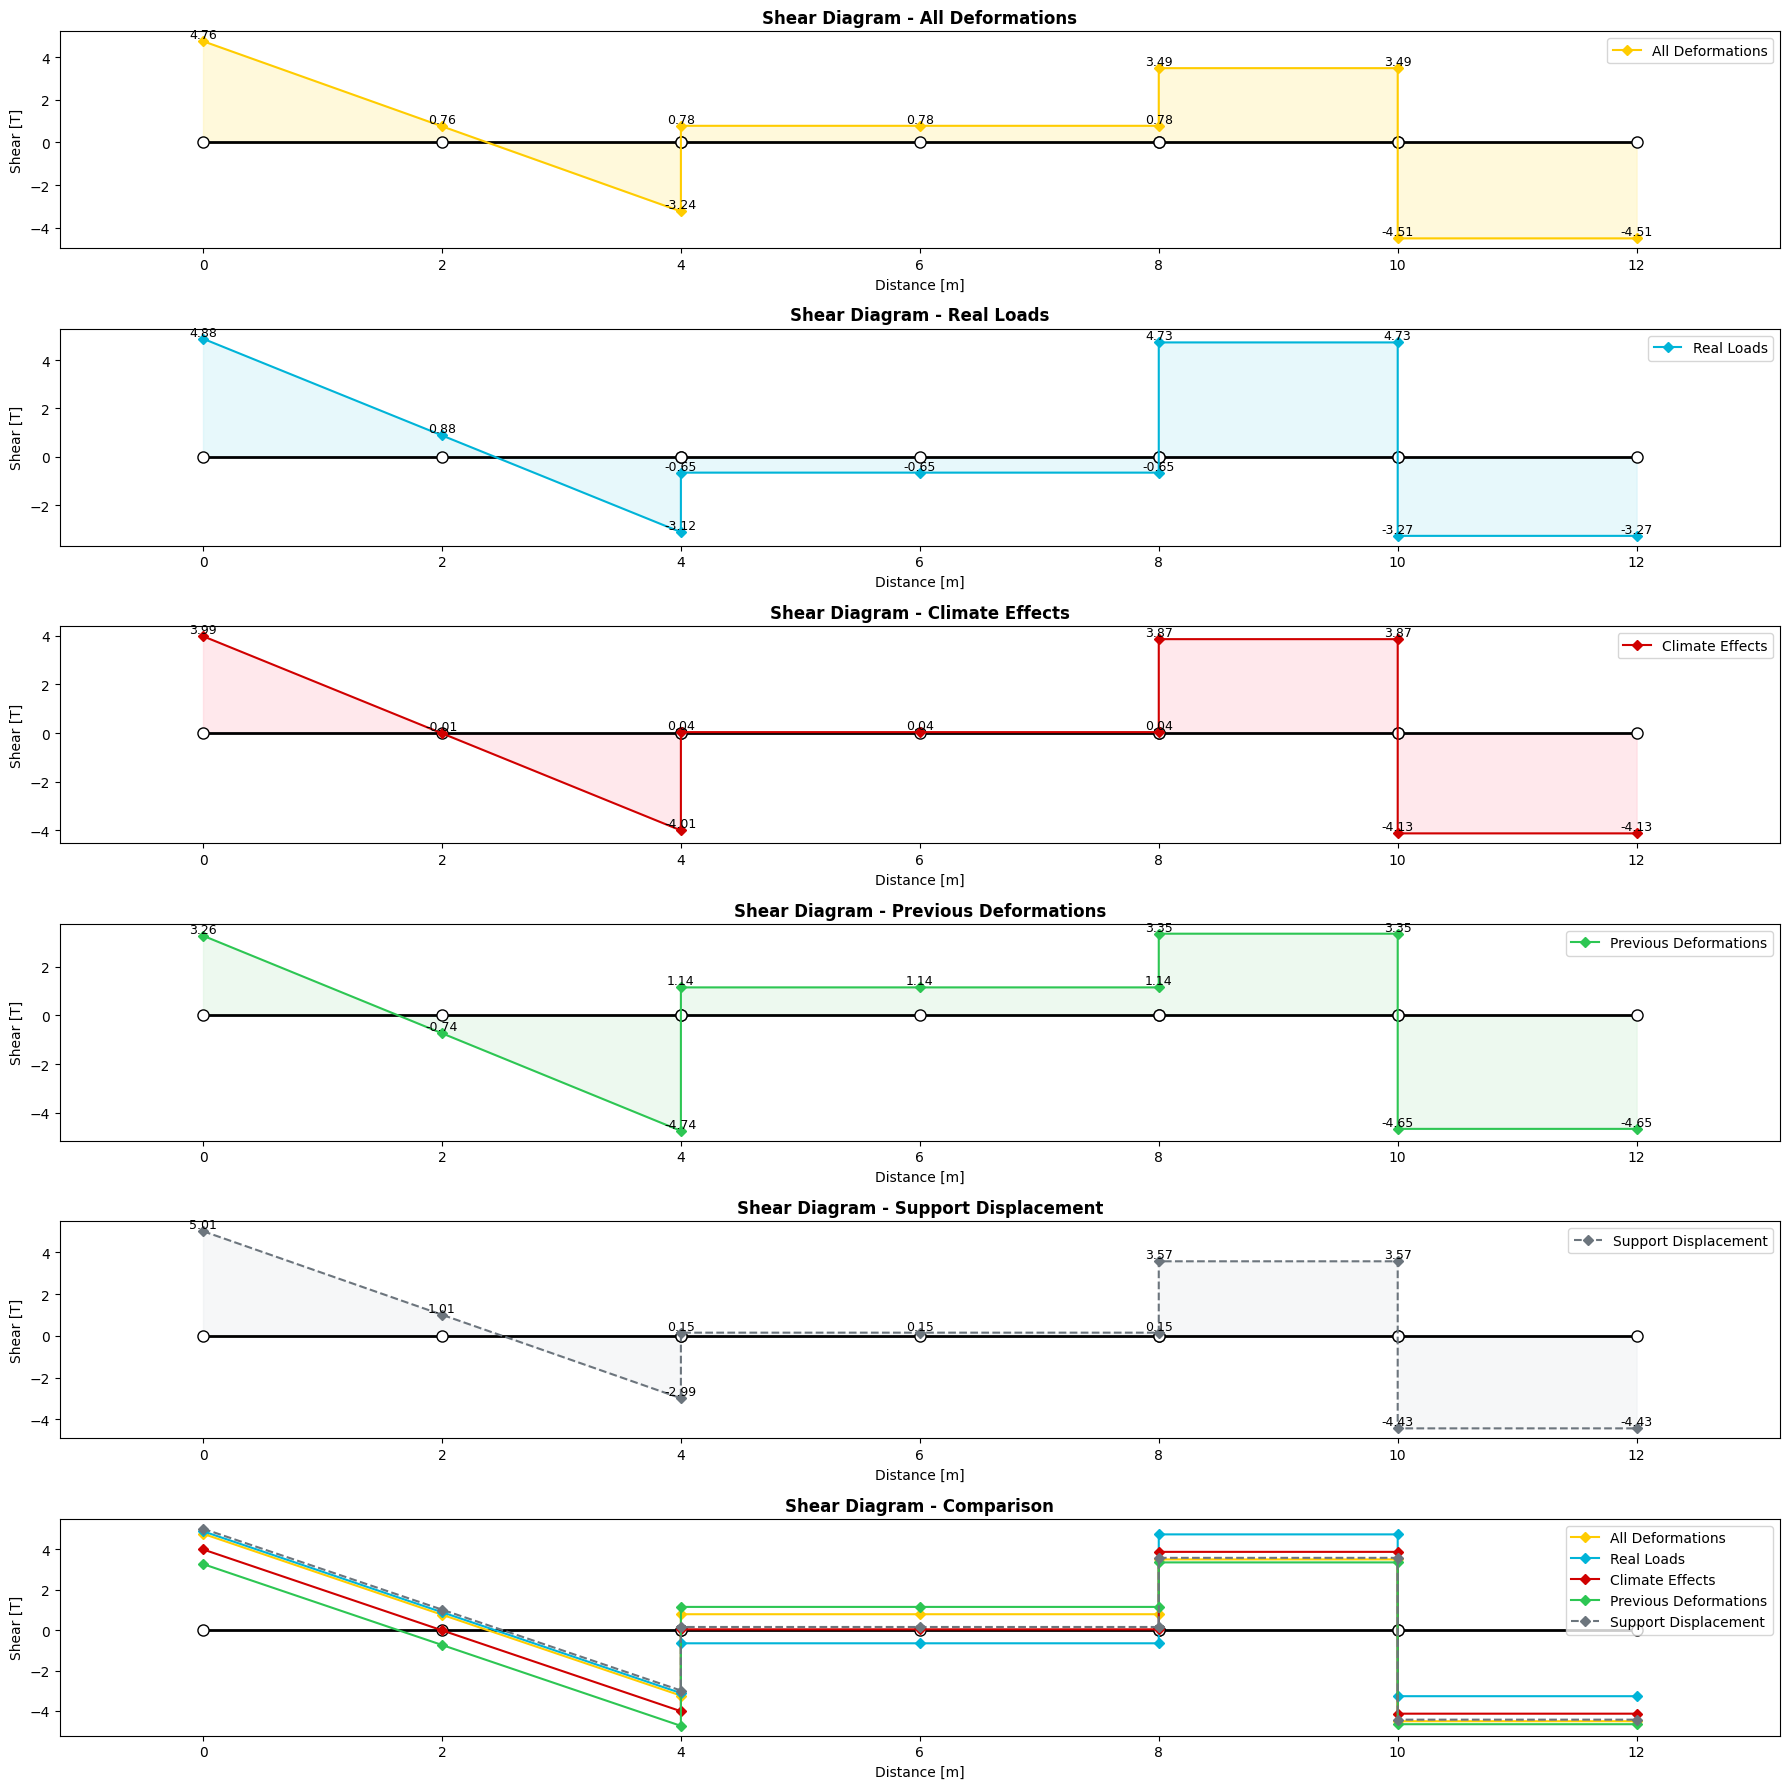

In [34]:
a1 = AM_all_v.flatten()
a2 = AM_L_v.flatten()
a3 = AM_T_v.flatten()
a4 = AM_P_v.flatten()
a5 = AM_R_v.flatten()

y_lab = 'Shear [T]'

grafico = FlexuralPlotManual(
    all_def=a1,
    real_load=a2,
    climate=a3,
    previous=a4,
    support=a5,
    x_vals=XF,
    ref_line=YF,
    y_label=y_lab
)

grafico.plot()